In [1]:
import pandas as pd
df = pd.read_csv('/Users/mipl/Downloads/manual_after_merging.csv')

In [2]:
# Stepwise Manual Pipeline (run each step cell manually)
# If ipyvizzu is missing, run this once in a new cell:
# %pip install ipyvizzu

import numpy as np
import pandas as pd
import plotly.express as px

from scipy import stats

from sklearn.model_selection import (
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)

try:
    from ipyvizzu import Chart, Data, Config
    IPYVIZZU_OK = True
except Exception:
    IPYVIZZU_OK = False
    print("ipyvizzu not available. Install with: %pip install ipyvizzu")


# Shared configuration
base_features = [
    "Kiln_Major_Axis",
    "Kiln_Minor_Axis",
    "Biochar_Major_Axis",
    "Biochar_Minor_Axis",
    "Mean_Distance",
    "Scaling_Factor",
]
target_col = "Volume"

selected_features = [
    "Kiln_Major_Axis",
    "Kiln_Minor_Axis",
    "Biochar_Major_Axis",
    "Biochar_Minor_Axis",
    "Mean_Distance",
    "Scaling_Factor",
    "Kiln_Sphericity_Ratio",
    "Biochar_Sphericity_Ratio",
    "Relative_Shrinkage_Major",
    "Relative_Shrinkage_Minor",
    "Relative_Shrinkage_Mean",
]

chosen_model_name = "RandomForestRegressor"


def add_engineered_features(data: pd.DataFrame) -> pd.DataFrame:
    df_eng = data.copy()
    eps = 1e-9
    df_eng["Kiln_Sphericity_Ratio"] = df_eng["Kiln_Major_Axis"] / (df_eng["Kiln_Minor_Axis"] + eps)
    df_eng["Biochar_Sphericity_Ratio"] = df_eng["Biochar_Major_Axis"] / (df_eng["Biochar_Minor_Axis"] + eps)
    df_eng["Relative_Shrinkage_Major"] = (
        (df_eng["Kiln_Major_Axis"] - df_eng["Biochar_Major_Axis"])
        / (df_eng["Kiln_Major_Axis"] + eps)
    )
    df_eng["Relative_Shrinkage_Minor"] = (
        (df_eng["Kiln_Minor_Axis"] - df_eng["Biochar_Minor_Axis"])
        / (df_eng["Kiln_Minor_Axis"] + eps)
    )
    df_eng["Relative_Shrinkage_Mean"] = (
        df_eng["Relative_Shrinkage_Major"] + df_eng["Relative_Shrinkage_Minor"]
    ) / 2
    return df_eng


def iqr_filter(data: pd.DataFrame, columns: list, multiplier: float = 1.5):
    mask_outlier = pd.Series(False, index=data.index)
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        col_outlier = (data[col] < lower) | (data[col] > upper)
        mask_outlier = mask_outlier | col_outlier
    return data.loc[~mask_outlier].copy(), mask_outlier


def scipy_feature_screening(data: pd.DataFrame, feature_cols: list, target: str) -> pd.DataFrame:
    rows = []
    for feat in feature_cols:
        clean = data[[feat, target]].dropna()
        if clean.shape[0] < 3:
            rows.append({"Feature": feat, "Pearson_r": np.nan, "Abs_r": np.nan, "p_value": np.nan, "Significant_0.05": False})
            continue
        r_val, p_val = stats.pearsonr(clean[feat], clean[target])
        rows.append({"Feature": feat, "Pearson_r": r_val, "Abs_r": abs(r_val), "p_value": p_val, "Significant_0.05": p_val < 0.05})
    return pd.DataFrame(rows).sort_values(by=["Significant_0.05", "Abs_r"], ascending=[False, False])


def get_model_and_param_space(model_name: str):
    model_map = {
        "LinearRegression": (LinearRegression(), {}, "none"),
        "Ridge": (Ridge(random_state=42), {"model__alpha": np.logspace(-4, 3, 30)}, "grid"),
        "Lasso": (Lasso(random_state=42, max_iter=20000), {"model__alpha": np.logspace(-4, 1, 20)}, "grid"),
        "ElasticNet": (
            ElasticNet(random_state=42, max_iter=20000),
            {"model__alpha": np.logspace(-4, 1, 20), "model__l1_ratio": np.linspace(0.1, 0.9, 9)},
            "random",
        ),
        "SVR": (
            SVR(),
            {"model__kernel": ["rbf", "linear"], "model__C": np.logspace(-1, 2, 10), "model__epsilon": [0.01, 0.05, 0.1, 0.2], "model__gamma": ["scale", "auto"]},
            "random",
        ),
        "KNeighborsRegressor": (
            KNeighborsRegressor(),
            {"model__n_neighbors": list(range(3, 31, 2)), "model__weights": ["uniform", "distance"], "model__p": [1, 2]},
            "grid",
        ),
        "DecisionTreeRegressor": (
            DecisionTreeRegressor(random_state=42),
            {"model__max_depth": [None, 4, 8, 12, 16], "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4]},
            "grid",
        ),
        "RandomForestRegressor": (
            RandomForestRegressor(random_state=42),
            {"model__n_estimators": [200, 400, 800], "model__max_depth": [None, 8, 16, 24], "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4]},
            "random",
        ),
        "ExtraTreesRegressor": (
            ExtraTreesRegressor(random_state=42),
            {"model__n_estimators": [200, 400, 800], "model__max_depth": [None, 8, 16, 24], "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4]},
            "random",
        ),
        "GradientBoostingRegressor": (
            GradientBoostingRegressor(random_state=42),
            {"model__n_estimators": [100, 300, 500], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [2, 3, 4], "model__subsample": [0.8, 1.0]},
            "random",
        ),
        "AdaBoostRegressor": (
            AdaBoostRegressor(random_state=42),
            {"model__n_estimators": [100, 300, 500], "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]},
            "grid",
        ),
    }
    if model_name not in model_map:
        fallback = "RandomForestRegressor"
        print(f"'{model_name}' not found. Using '{fallback}'.")
        return model_map[fallback], fallback
    return model_map[model_name], model_name


print("Setup loaded. Run Step 1 next.")

Setup loaded. Run Step 1 next.


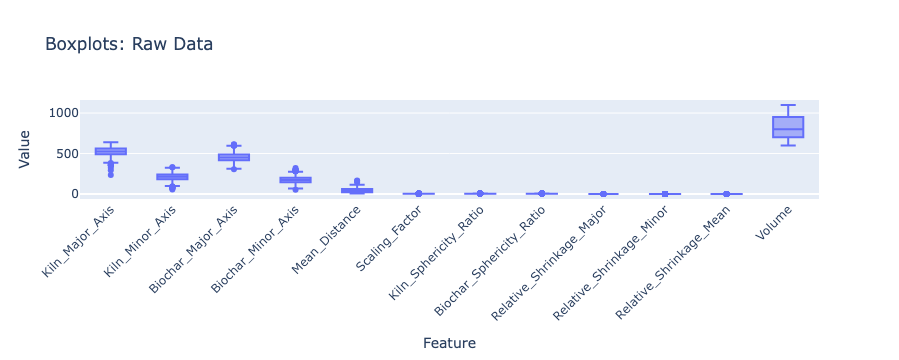

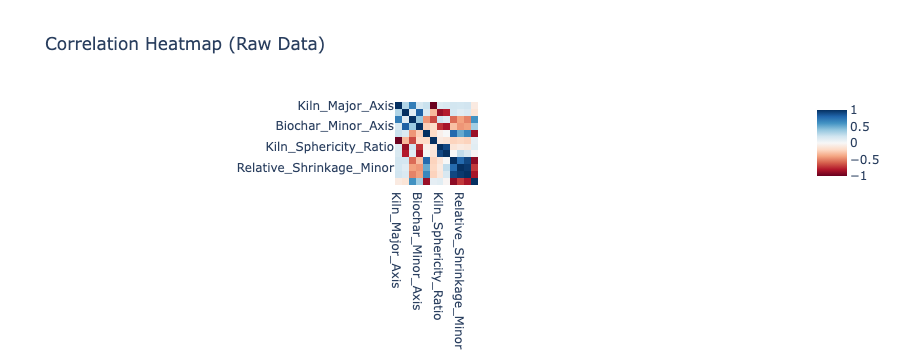

Rows before: 3544
Outliers flagged: 162
Rows after: 3382
Step 1 complete. Run Step 2.


In [3]:
# STEP 1: Data pre-processing
required_cols = list(set(base_features + [target_col]))
work_df = df[required_cols].dropna(subset=[target_col]).copy()
work_df = add_engineered_features(work_df)

valid_selected_features = [f for f in selected_features if f in work_df.columns]
missing_selected = [f for f in selected_features if f not in work_df.columns]
if missing_selected:
    print("Missing selected features ignored:", missing_selected)

if len(valid_selected_features) == 0:
    raise ValueError("No valid selected features. Update selected_features.")

eda_cols = valid_selected_features + [target_col]
long_df = work_df[eda_cols].melt(var_name="Feature", value_name="Value")
px.box(long_df, x="Feature", y="Value", points="outliers", title="Boxplots: Raw Data").update_layout(xaxis_tickangle=-45).show()

corr_cols = list(dict.fromkeys(valid_selected_features + [target_col]))
px.imshow(work_df[corr_cols].corr(), text_auto=True, color_continuous_scale="RdBu", zmin=-1, zmax=1, title="Correlation Heatmap (Raw Data)").show()

filtered_df, outlier_mask = iqr_filter(work_df, corr_cols, multiplier=1.5)
print("Rows before:", len(work_df))
print("Outliers flagged:", int(outlier_mask.sum()))
print("Rows after:", len(filtered_df))

print("Step 1 complete. Run Step 2.")

In [4]:
# STEP 2: Feature selection (SciPy screening)
screen_df = scipy_feature_screening(filtered_df, valid_selected_features, target_col)
print(screen_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

# Optional: keep only significant features (manual toggle)
use_significant_only = False
if use_significant_only:
    sig = screen_df.loc[screen_df["Significant_0.05"], "Feature"].tolist()
    model_features = sig if len(sig) > 0 else valid_selected_features
else:
    model_features = valid_selected_features

print("\nModel features:", model_features)

if IPYVIZZU_OK:
    viz_df = screen_df.copy().head(12)[["Feature", "Abs_r"]].rename(columns={"Abs_r": "AbsCorrelation"})
    chart = Chart()
    data = Data()
    data.add_df(viz_df)
    chart.animate(data)
    chart.animate(Config({
        "channels": {
            "y": "Feature",
            "x": "AbsCorrelation",
            "label": "AbsCorrelation",
            "color": "Feature",
        },
        "geometry": "rectangle",
        "title": "Feature Strength (|Pearson r|)"
    }))

print("Step 2 complete. Run Step 3.")

                 Feature  Pearson_r   Abs_r  p_value  Significant_0.05
Relative_Shrinkage_Major   -0.95073 0.95073  0.00000              True
           Mean_Distance   -0.90515 0.90515  0.00000              True
 Relative_Shrinkage_Mean   -0.90506 0.90506  0.00000              True
Relative_Shrinkage_Minor   -0.80334 0.80334  0.00000              True
      Biochar_Major_Axis    0.61809 0.61809  0.00000              True
      Biochar_Minor_Axis    0.36101 0.36101  0.00000              True
         Kiln_Minor_Axis   -0.13259 0.13259  0.00000              True
   Kiln_Sphericity_Ratio    0.11103 0.11103  0.00000              True
         Kiln_Major_Axis   -0.08487 0.08487  0.00000              True
          Scaling_Factor    0.08300 0.08300  0.00000              True
Biochar_Sphericity_Ratio   -0.01857 0.01857  0.28026             False

Model features: ['Kiln_Major_Axis', 'Kiln_Minor_Axis', 'Biochar_Major_Axis', 'Biochar_Minor_Axis', 'Mean_Distance', 'Scaling_Factor', 'Kiln_Spheric

Step 2 complete. Run Step 3.


In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import shap

# 1. PRE-SCREEN: Remove perfectly redundant features (Fixes the Divide by Zero)
def remove_perfect_collinearity(df, features):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Drop features with correlation > 0.98 to avoid VIF infinity
    to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]
    return [f for f in features if f not in to_drop]

initial_features = remove_perfect_collinearity(filtered_df, valid_selected_features)

# 2. VIF: Iterative cleaning
def calculate_vif(df, features):
    if not features: return pd.DataFrame(columns=["Feature", "VIF"])
    X = df[features].dropna()
    # Add a small amount of noise (jitter) to prevent singular matrices if needed
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
    return vif_data

vif_df = calculate_vif(filtered_df, initial_features)
low_vif_features = vif_df[vif_df["VIF"] < 10]["Feature"].tolist()

# 3. SAFETY CHECK: Ensure we still have features
if len(low_vif_features) == 0:
    print("Warning: VIF removed all features. Falling back to top 5 correlations.")
    low_vif_features = initial_features[:5] 

# 4. LASSO & SHAP (Now protected from empty lists)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(filtered_df[low_vif_features])
y = filtered_df[target_col].values

lasso = LassoCV(cv=5, max_iter=10000).fit(X_scaled, y)
lasso_features = [f for f, coef in zip(low_vif_features, lasso.coef_) if abs(coef) > 1e-5]

# Final fallback
if not lasso_features:
    lasso_features = low_vif_features

print(f"Final features for SHAP: {lasso_features}")

Final features for SHAP: ['Kiln_Major_Axis', 'Kiln_Minor_Axis', 'Biochar_Major_Axis', 'Biochar_Minor_Axis', 'Mean_Distance']


/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [10]:
vif_df

,Feature,VIF
0,Kiln_Major_Axis,1.700096e+04
1,Kiln_Minor_Axis,5.064715e+03
2,Biochar_Major_Axis,1.847850e+04
3,Biochar_Minor_Axis,3.970667e+03
4,Mean_Distance,6.922831e+01
5,Kiln_Sphericity_Ratio,4.546042e+03
6,Biochar_Sphericity_Ratio,4.643037e+03
7,Relative_Shrinkage_Major,inf
8,Relative_Shrinkage_Minor,inf
9,Relative_Shrinkage_Mean,inf


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure we are using the filtered list from Step 2
# Fallback: if model_features was never defined, use valid_selected_features
final_features = model_features if 'model_features' in locals() else valid_selected_features

X = filtered_df[lasso_features].copy()
y = filtered_df[target_col].copy()

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scaling (Crucial for SVR, KNN, and Regularized Models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names (helpful for model interpretation later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=lasso_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=lasso_features)

print(f"--- Step 3 Summary ---")
print(f"Selected Features ({len(lasso_features)}): {lasso_features}")
print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape:  {X_test_scaled.shape}")

# Candidate models list
candidate_models = [
    "LinearRegression", "Ridge", "Lasso", "ElasticNet",
    "SVR", "KNeighborsRegressor", "DecisionTreeRegressor",
    "RandomForestRegressor", "ExtraTreesRegressor",
    "GradientBoostingRegressor", "AdaBoostRegressor",
]

if chosen_model_name not in candidate_models:
    print(f"\nWarning: '{chosen_model_name}' is not in candidate_models.")
else:
    print(f"\nTarget Model: {chosen_model_name}")

print("\nStep 3 complete. Data is scaled and split. Run Step 4.")

--- Step 3 Summary ---
Selected Features (5): ['Kiln_Major_Axis', 'Kiln_Minor_Axis', 'Biochar_Major_Axis', 'Biochar_Minor_Axis', 'Mean_Distance']
Training shape: (2705, 5)
Testing shape:  (677, 5)

Target Model: RandomForestRegressor

Step 3 complete. Data is scaled and split. Run Step 4.


In [15]:

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
import numpy as np

# Use the features curated in Step 2
final_features = model_features if 'model_features' in locals() else valid_selected_features
X_cv = filtered_df[lasso_features]
y_cv = filtered_df[target_col]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
preview_rows = []

print(f"Running CV on {len(lasso_features)} features...")

for model_name in candidate_models:
    # Get model object (assuming get_model_and_param_space is defined in your utils)
    (model_obj, _, _), _resolved = get_model_and_param_space(model_name)
    
    # Create pipeline to ensure scaling happens WITHIN the CV loop 
    # This prevents data leakage from the validation fold
    pipe = Pipeline([
        ("scaler", StandardScaler()), 
        ("model", model_obj)
    ])
    
    scores = cross_validate(
        pipe,
        X_cv,
        y_cv,
        cv=cv,
        scoring={
            "r2": "r2", 
            "mae": "neg_mean_absolute_error", 
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1,
        error_score='raise' 
    )
    
    preview_rows.append({
        "Model": model_name,
        "R2_mean": np.mean(scores["test_r2"]),
        "R2_std": np.std(scores["test_r2"]), # Stability check
        "MAE_mean": -np.mean(scores["test_mae"]),
        "RMSE_mean": -np.mean(scores["test_rmse"]),
    })

# Organize results
preview_df = pd.DataFrame(preview_rows).sort_values("R2_mean", ascending=False)

# Display table
print("\n--- Model Performance Comparison (Ordered by R2) ---")
print(preview_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

# Visualization
if IPYVIZZU_OK:
    viz_df = preview_df.head(10).copy()
    chart = Chart()
    data = Data()
    data.add_df(viz_df[["Model", "R2_mean"]].rename(columns={"R2_mean": "R2"}))
    chart.animate(data)
    chart.animate(Config({
        "channels": {
            "y": {"set": ["Model"]},
            "x": {"set": ["R2"]},
            "label": {"set": ["R2"]},
            "color": {"set": ["Model"]},
        },
        "geometry": "rectangle",
        "title": f"Model Preview: 5-Fold CV R2 using {len(final_features)} Features"
    }))

print("\nStep 4 complete. Check 'R2_std' for stability.")
print(f"Recommended model based on R2: {preview_df.iloc[0]['Model']}")

Running CV on 5 features...

--- Model Performance Comparison (Ordered by R2) ---
                    Model  R2_mean  R2_std  MAE_mean  RMSE_mean
GradientBoostingRegressor  0.91097 0.00604  32.55626   42.76199
    RandomForestRegressor  0.90648 0.00540  33.19721   43.83588
      ExtraTreesRegressor  0.90550 0.00569  33.34146   44.06330
      KNeighborsRegressor  0.90353 0.00482  34.23722   44.52446
                    Ridge  0.90351 0.00520  34.86200   44.52546
         LinearRegression  0.90350 0.00525  34.86480   44.52610
                    Lasso  0.90190 0.00456  35.01554   44.89899
        AdaBoostRegressor  0.86932 0.00616  41.63459   51.82571
               ElasticNet  0.83186 0.00411  47.67263   58.80023
                      SVR  0.82772 0.00574  46.63434   59.51232
    DecisionTreeRegressor  0.81883 0.00726  42.96264   61.02490



Step 4 complete. Check 'R2_std' for stability.
Recommended model based on R2: GradientBoostingRegressor


--- Finalizing Model: GradientBoostingRegressor ---


/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

Best Params: {'model__subsample': 0.8, 'model__num_leaves': 31, 'model__n_estimators': 300, 'model__learning_rate': 0.05}


/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Final Diagnostic for LGBMRegressor
R^2 : 0.91368 | MAE : 32.34671 | RMSE: 42.16362


/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


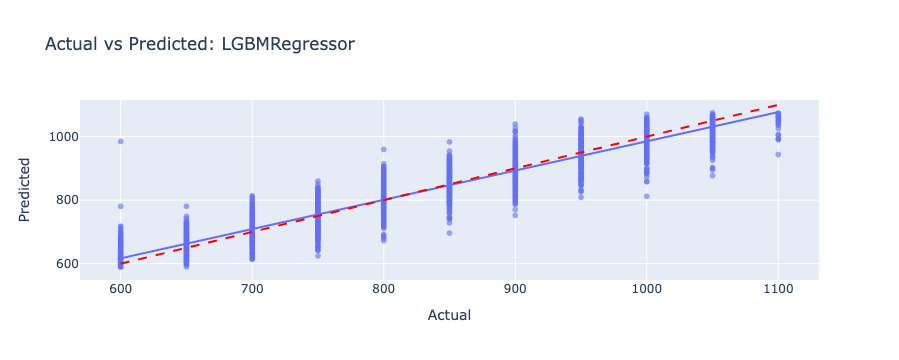


Generating SHAP explanations...


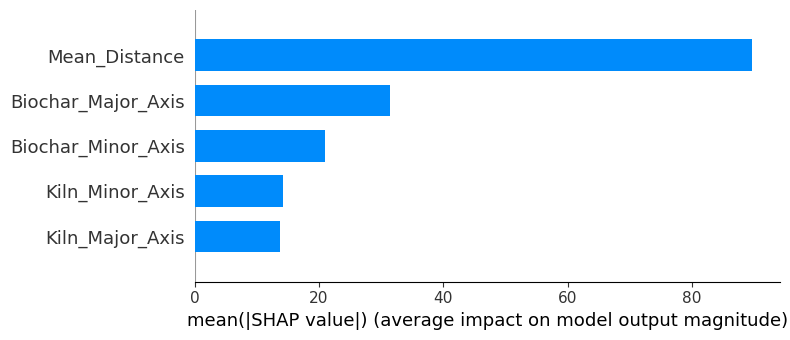

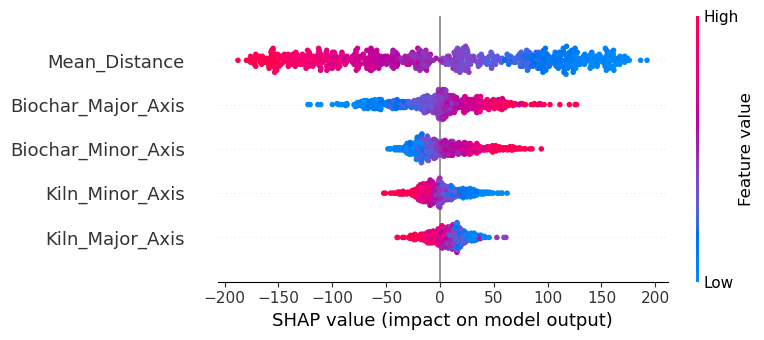

Step 5 complete.


In [23]:
import shap
import numpy as np
import pandas as pd
import plotly.express as px
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 1. CONFIGURATION ---
chosen_model_name = "GradientBoostingRegressor"

# We define the model logic here in case it's not in your global helper function yet
def get_lgbm_setup():
    model = LGBMRegressor(random_state=42, verbose=-1)
    params = {
        "model__n_estimators": [100, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 50, 100],
        "model__subsample": [0.8, 1.0]
    }
    return (model, params, "random"), "LGBMRegressor"

print(f"--- Finalizing Model: {chosen_model_name} ---")

# Setup the specific model
(model_obj, param_space, search_type), resolved_model_name = get_lgbm_setup()
pipe = Pipeline([("scaler", StandardScaler()), ("model", model_obj)])

# --- 2. HYPERPARAMETER OPTIMIZATION ---
if search_type == "none":
    best_model = pipe.fit(X_train, y_train)
    print("Direct fit completed.")
else:
    # Using RandomizedSearch to save time with LGBM's complexity
    searcher = RandomizedSearchCV(
        pipe, param_distributions=param_space, n_iter=20, 
        scoring="r2", cv=cv, random_state=42, n_jobs=-1, refit=True
    )
    searcher.fit(X_train, y_train)
    best_model = searcher.best_estimator_
    print("Best Params:", searcher.best_params_)

# --- 3. PERFORMANCE EVALUATION ---
y_cv_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
r2 = r2_score(y, y_cv_pred)
mae = mean_absolute_error(y, y_cv_pred)
rmse = np.sqrt(mean_squared_error(y, y_cv_pred))

print(f"\nFinal Diagnostic for {resolved_model_name}")
print(f"R^2 : {r2:.5f} | MAE : {mae:.5f} | RMSE: {rmse:.5f}")

# --- 4. VISUAL DIAGNOSTICS ---
diag_df = pd.DataFrame({"Actual": y, "Predicted": y_cv_pred})
fig_ap = px.scatter(diag_df, x="Actual", y="Predicted", trendline="ols",
                   title=f"Actual vs Predicted: {resolved_model_name}", opacity=0.6)
fig_ap.add_shape(type="line", x0=y.min(), y0=y.min(), x1=y.max(), y1=y.max(), 
                 line=dict(color="red", dash="dash"))
fig_ap.show()

# --- 5. SHAP INTERPRETABILITY ---
print("\nGenerating SHAP explanations...")
# Extract the trained model and the scaler
final_model_step = best_model.named_steps['model']

# SHAP needs the data in the same state the model saw it (Scaled)
# Use X_test_scaled from your Step 3
explainer = shap.TreeExplainer(final_model_step)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plots
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")
shap.summary_plot(shap_values, X_test_scaled)

print("Step 5 complete.")

In [8]:
# STEP 6: Advanced model search (state-of-the-art within scikit-learn)
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold

# Stronger CV for screening
strict_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# Advanced candidates (balanced for tabular regression)
advanced_models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR_RBF": SVR(kernel="rbf"),
    "KNN": KNeighborsRegressor(),
    "ElasticNet": ElasticNet(random_state=42, max_iter=20000),
}

# Stacking ensemble (often strong on structured tabular data)
stack_base = [
    ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    ("et", ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    ("gbr", GradientBoostingRegressor(random_state=42)),
]
advanced_models["StackingEnsemble"] = StackingRegressor(
    estimators=stack_base,
    final_estimator=Ridge(alpha=1.0),
    passthrough=False,
    n_jobs=-1,
)

# Parameter spaces for randomized tuning on strongest nonlinear models
advanced_param_spaces = {
    "HistGradientBoosting": {
        "model__regressor__max_iter": [200, 400, 800],
        "model__regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__regressor__max_depth": [None, 4, 8, 12],
        "model__regressor__min_samples_leaf": [10, 20, 30, 50],
        "model__regressor__l2_regularization": [0.0, 0.01, 0.1, 1.0],
    },
    "RandomForest": {
        "model__regressor__n_estimators": [300, 600, 900],
        "model__regressor__max_depth": [None, 10, 20, 30],
        "model__regressor__min_samples_split": [2, 5, 10],
        "model__regressor__min_samples_leaf": [1, 2, 4],
        "model__regressor__max_features": ["sqrt", "log2", 0.7],
    },
    "ExtraTrees": {
        "model__regressor__n_estimators": [300, 600, 900],
        "model__regressor__max_depth": [None, 10, 20, 30],
        "model__regressor__min_samples_split": [2, 5, 10],
        "model__regressor__min_samples_leaf": [1, 2, 4],
        "model__regressor__max_features": ["sqrt", "log2", 0.7],
    },
    "GradientBoosting": {
        "model__regressor__n_estimators": [200, 400, 700],
        "model__regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__regressor__max_depth": [2, 3, 4, 5],
        "model__regressor__subsample": [0.7, 0.85, 1.0],
        "model__regressor__min_samples_leaf": [1, 2, 4],
    },
    "SVR_RBF": {
        "model__regressor__C": np.logspace(-1, 3, 12),
        "model__regressor__epsilon": [0.001, 0.01, 0.05, 0.1, 0.2],
        "model__regressor__gamma": ["scale", "auto"],
    },
    "KNN": {
        "model__regressor__n_neighbors": list(range(3, 41, 2)),
        "model__regressor__weights": ["uniform", "distance"],
        "model__regressor__p": [1, 2],
    },
    "ElasticNet": {
        "model__regressor__alpha": np.logspace(-5, 1, 20),
        "model__regressor__l1_ratio": np.linspace(0.05, 0.95, 19),
    },
    "StackingEnsemble": {},
}

advanced_results = []
advanced_fitted = {}

for name, base_model in advanced_models.items():
    # Target transformation improves stability when volume distribution is skewed
    ttr = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ttr),
    ])

    param_space = advanced_param_spaces.get(name, {})

    if len(param_space) > 0:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_space,
            n_iter=35,
            scoring="neg_root_mean_squared_error",
            cv=5,
            random_state=42,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        best_params = search.best_params_
    else:
        best_estimator = pipeline.fit(X_train, y_train)
        best_params = "Default"

    cv_scores = cross_validate(
        best_estimator,
        X,
        y,
        cv=strict_cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        n_jobs=-1,
    )

    r2_mean = float(np.mean(cv_scores["test_r2"]))
    mae_mean = float(-np.mean(cv_scores["test_mae"]))
    rmse_mean = float(-np.mean(cv_scores["test_rmse"]))
    rmse_mae_gap = abs(rmse_mean - mae_mean)

    advanced_results.append(
        {
            "Model": name,
            "R2_mean": r2_mean,
            "MAE_mean": mae_mean,
            "RMSE_mean": rmse_mean,
            "|RMSE-MAE|": rmse_mae_gap,
            "BestParams": str(best_params)[:160],
        }
    )
    advanced_fitted[name] = best_estimator

advanced_df = pd.DataFrame(advanced_results).sort_values(
    by=["RMSE_mean", "MAE_mean", "|RMSE-MAE|", "R2_mean"],
    ascending=[True, True, True, False],
)

print("Advanced screening leaderboard (lower RMSE/MAE/gap is better):")
print(advanced_df[["Model", "R2_mean", "MAE_mean", "RMSE_mean", "|RMSE-MAE|"]].to_string(index=False, float_format=lambda v: f"{v:.5f}"))

if IPYVIZZU_OK:
    viz_rank = advanced_df[["Model", "RMSE_mean"]].copy().sort_values("RMSE_mean", ascending=False)
    chart = Chart()
    data = Data()
    data.add_df(viz_rank)
    chart.animate(data)
    chart.animate(Config({
        "channels": {"y": "Model", "x": "RMSE_mean", "label": "RMSE_mean", "color": "Model"},
        "geometry": "rectangle",
        "title": "Advanced Models: RMSE Comparison"
    }))

best_advanced_model_name = advanced_df.iloc[0]["Model"]
best_advanced_model = advanced_fitted[best_advanced_model_name]
print(f"\nBest advanced model selected for strict verification: {best_advanced_model_name}")
print("Step 6 complete. Run Step 7.")

/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.740e-02, tolerance: 6.992e-03
  model = cd_fast.enet_coordinate_descent(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.742e-02, tolerance: 6.920e-03
  model = cd_fast.enet_coordinate_descent(
/Users/mipl/miniconda3/envs/py_gis/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

Advanced screening leaderboard (lower RMSE/MAE/gap is better):
               Model  R2_mean  MAE_mean  RMSE_mean  |RMSE-MAE|
             SVR_RBF  0.92898  29.34197   38.16453     8.82256
          ExtraTrees  0.92885  29.58474   38.20072     8.61598
        RandomForest  0.92840  29.65154   38.32015     8.66862
    GradientBoosting  0.92773  29.79620   38.50383     8.70762
HistGradientBoosting  0.92724  29.88376   38.63699     8.75323
    StackingEnsemble  0.92688  29.90065   38.73155     8.83090
                 KNN  0.92412  31.01774   39.45539     8.43765
          ElasticNet  0.92041  31.30638   40.39052     9.08414



Best advanced model selected for strict verification: SVR_RBF
Step 6 complete. Run Step 7.


In [9]:
# STEP 7: Strict verification and final diagnostics
from sklearn.model_selection import RepeatedKFold

verification_cv = KFold(n_splits=5, shuffle=True, random_state=123)

# OOF-style repeated CV metrics for robust estimate
oof_pred = cross_val_predict(best_advanced_model, X, y, cv=verification_cv, n_jobs=-1)
cv_r2 = r2_score(y, oof_pred)
cv_mae = mean_absolute_error(y, oof_pred)
cv_rmse = np.sqrt(mean_squared_error(y, oof_pred))
cv_gap = abs(cv_rmse - cv_mae)

# Fit on train and evaluate on untouched test split for sanity check
best_advanced_model.fit(X_train, y_train)
test_pred = best_advanced_model.predict(X_test)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_gap = abs(test_rmse - test_mae)

print("===== Strict Verification Report =====")
print(f"Selected model       : {best_advanced_model_name}")
print("\nRepeated CV (5x5) on full data")
print(f"R^2                  : {cv_r2:.5f}")
print(f"MAE                  : {cv_mae:.5f}")
print(f"RMSE                 : {cv_rmse:.5f}")
print(f"|RMSE - MAE|         : {cv_gap:.5f}")

print("\nUntouched hold-out test")
print(f"R^2                  : {test_r2:.5f}")
print(f"MAE                  : {test_mae:.5f}")
print(f"RMSE                 : {test_rmse:.5f}")
print(f"|RMSE - MAE|         : {test_gap:.5f}")

# Visual diagnostics
diag_cv = pd.DataFrame({"Actual": y, "Predicted": oof_pred})
fig_cv = px.scatter(diag_cv, x="Actual", y="Predicted", title=f"Strict CV: Actual vs Predicted ({best_advanced_model_name})", opacity=0.65)
mn = min(diag_cv["Actual"].min(), diag_cv["Predicted"].min())
mx = max(diag_cv["Actual"].max(), diag_cv["Predicted"].max())
fig_cv.add_shape(type="line", x0=mn, y0=mn, x1=mx, y1=mx, line=dict(color="red", dash="dash"))
fig_cv.show()

res_cv = y - oof_pred
px.histogram(res_cv, nbins=50, title="Strict CV Residual Distribution", labels={"value": "Residual (Actual - Predicted)"}).show()

if IPYVIZZU_OK:
    metrics_df = pd.DataFrame({
        "Metric": ["CV_MAE", "CV_RMSE", "Test_MAE", "Test_RMSE"],
        "Value": [cv_mae, cv_rmse, test_mae, test_rmse],
    })
    chart = Chart()
    data = Data()
    data.add_df(metrics_df)
    chart.animate(data)
    chart.animate(Config({
        "channels": {"x": "Metric", "y": "Value", "label": "Value", "color": "Metric"},
        "geometry": "rectangle",
        "title": "Verification Metrics"
    }))

print("Step 7 complete. This is the strict, advanced evaluation output.")

ValueError: cross_val_predict only works for partitions

In [12]:
# STEP 8: Bayesian models + game-theoretic ensemble
from sklearn.linear_model import BayesianRidge, ARDRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# Helper metric function

def _calc_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    gap = abs(rmse - mae)
    return r2, mae, rmse, gap

# 1) Bayesian candidate models
bayesian_models = {
    "BayesianRidge": BayesianRidge(),
    "ARDRegression": ARDRegression(),
    "GaussianProcess": GaussianProcessRegressor(
        kernel=C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        normalize_y=True,
        random_state=42,
    ),
}

bayes_results = []
bayes_oof_predictions = {}

for name, model in bayesian_models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    # Reuse strict CV defined in Step 6 (fallback if missing)
    try:
        cv_used = KFold(n_splits=5, shuffle=True, random_state=42)
    except NameError:
        cv_used = KFold(n_splits=5, shuffle=True, random_state=42)

    y_oof = cross_val_predict(pipe, X, y, cv=cv_used, n_jobs=-1)
    bayes_oof_predictions[name] = y_oof

    r2, mae, rmse, gap = _calc_metrics(y, y_oof)
    bayes_results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "|RMSE-MAE|": gap,
    })

bayes_df = pd.DataFrame(bayes_results).sort_values(by=["RMSE", "MAE", "|RMSE-MAE|", "R2"], ascending=[True, True, True, False])
print("Bayesian model comparison:")
print(bayes_df.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

# 2) Game-theory style model coalition (Shapley-inspired weighting)
# Idea: each model is a player; payoff is error reduction. Weight inversely by RMSE.
inv_rmse = 1 / bayes_df.set_index("Model")["RMSE"]
weights = (inv_rmse / inv_rmse.sum()).sort_values(ascending=False)

print("\nCoalition weights (inverse-RMSE payoff sharing):")
for m, w in weights.items():
    print(f"- {m}: {w:.4f}")

# Coalition prediction (weighted average of players)
coalition_pred = np.zeros(len(y), dtype=float)
for m, w in weights.items():
    coalition_pred += bayes_oof_predictions[m] * w

coal_r2, coal_mae, coal_rmse, coal_gap = _calc_metrics(y, coalition_pred)
print("\nGame-Theoretic Coalition Result (OOF CV predictions):")
print(f"R^2          : {coal_r2:.5f}")
print(f"MAE          : {coal_mae:.5f}")
print(f"RMSE         : {coal_rmse:.5f}")
print(f"|RMSE - MAE| : {coal_gap:.5f}")

# Compare best single Bayesian model vs coalition
best_single_name = bayes_df.iloc[0]["Model"]
best_single_pred = bayes_oof_predictions[best_single_name]
bs_r2, bs_mae, bs_rmse, bs_gap = _calc_metrics(y, best_single_pred)

compare_df = pd.DataFrame([
    {"Approach": f"Best Bayesian ({best_single_name})", "R2": bs_r2, "MAE": bs_mae, "RMSE": bs_rmse, "|RMSE-MAE|": bs_gap},
    {"Approach": "Game-Theoretic Coalition", "R2": coal_r2, "MAE": coal_mae, "RMSE": coal_rmse, "|RMSE-MAE|": coal_gap},
]).sort_values(by=["RMSE", "MAE", "|RMSE-MAE|", "R2"], ascending=[True, True, True, False])

print("\nBest-single vs coalition:")
print(compare_df.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

# Visual diagnostics
coal_diag = pd.DataFrame({"Actual": y, "Predicted": coalition_pred})
fig_coal = px.scatter(coal_diag, x="Actual", y="Predicted", title="Game-Theoretic Coalition: Actual vs Predicted", opacity=0.65)
mn = min(coal_diag["Actual"].min(), coal_diag["Predicted"].min())
mx = max(coal_diag["Actual"].max(), coal_diag["Predicted"].max())
fig_coal.add_shape(type="line", x0=mn, y0=mn, x1=mx, y1=mx, line=dict(color="red", dash="dash"))
fig_coal.show()

px.histogram(y - coalition_pred, nbins=50, title="Game-Theoretic Coalition Residual Distribution", labels={"value": "Residual (Actual - Predicted)"}).show()

if IPYVIZZU_OK:
    viz = compare_df[["Approach", "RMSE"]].copy().sort_values("RMSE", ascending=False)
    chart = Chart()
    data = Data()
    data.add_df(viz)
    chart.animate(data)
    chart.animate(Config({
        "channels": {"y": "Approach", "x": "RMSE", "label": "RMSE", "color": "Approach"},
        "geometry": "rectangle",
        "title": "Bayesian vs Coalition RMSE"
    }))

print("Step 8 complete.")

ValueError: cross_val_predict only works for partitions